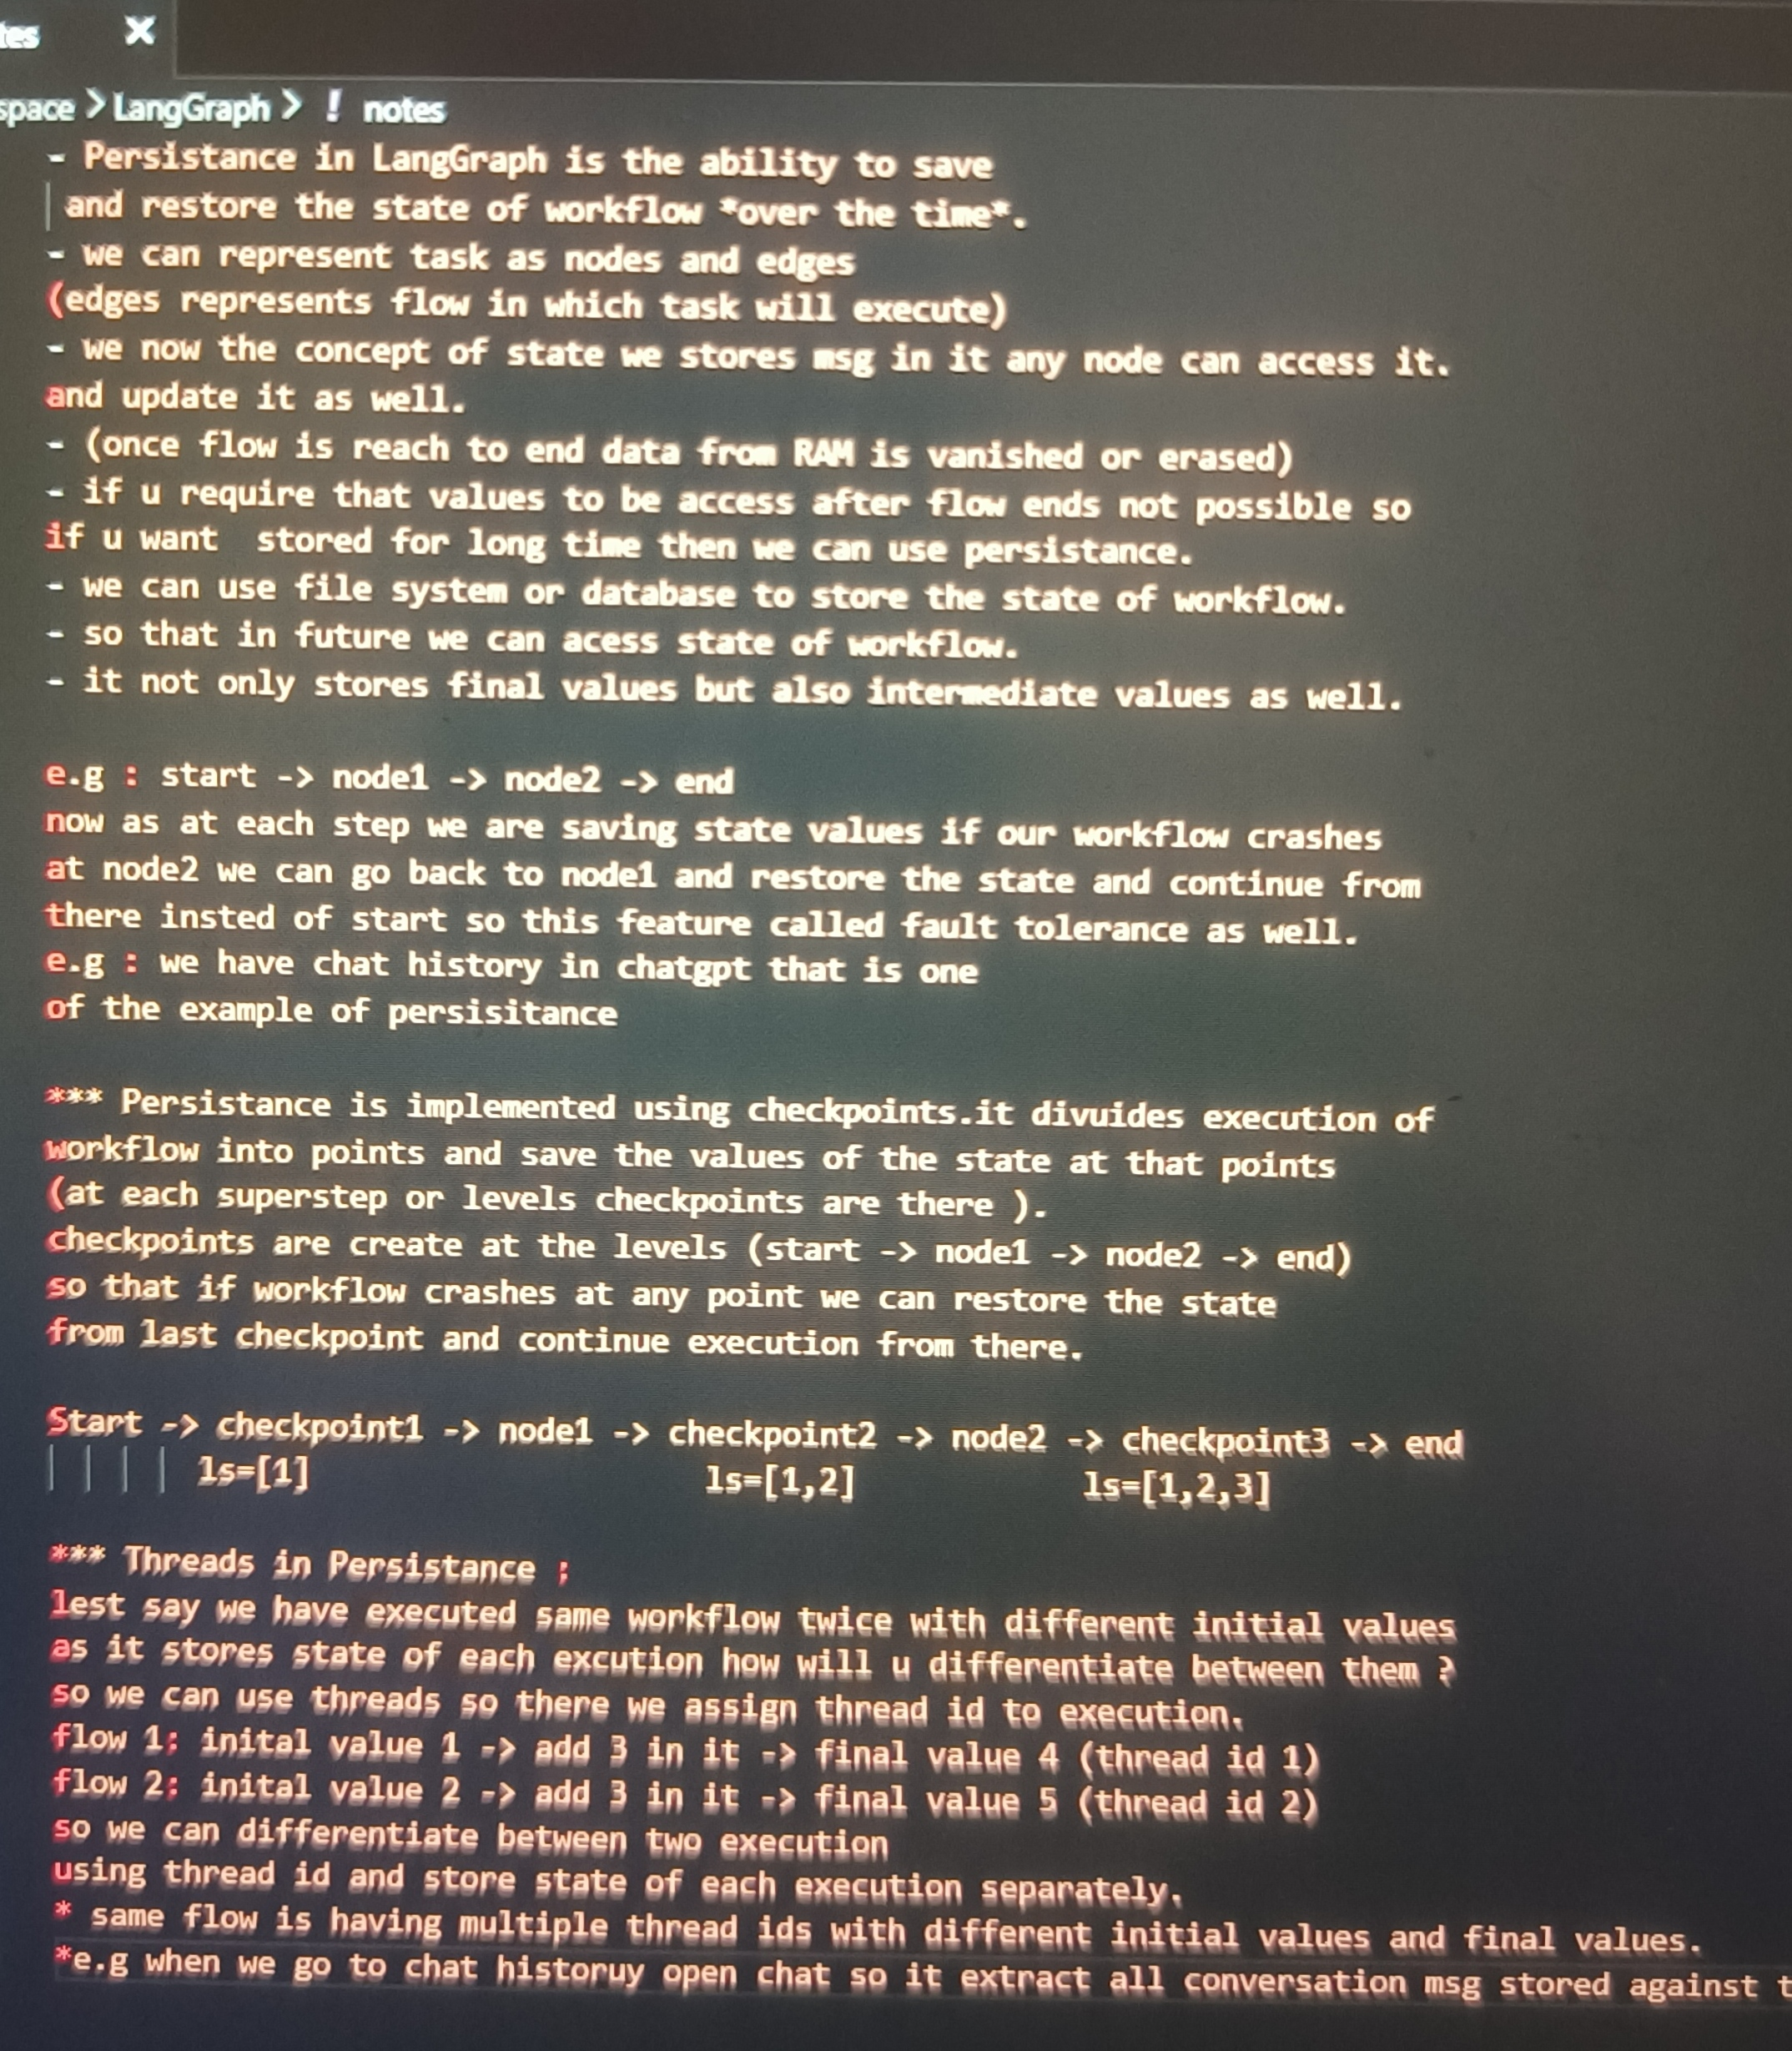

In [2]:
from IPython.display import Image, display

display(Image(filename='persistance.jpg'))

In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict
from langchain_ollama import ChatOllama
from langgraph.checkpoint.memory import InMemorySaver

In [4]:
llm=ChatOllama(model="llama3.2:1b")

In [6]:
llm.invoke("Hi").content

'Hello. Is there something I can help you with or would you like to chat?'

In [8]:
# define state for code 
class JokeState(TypedDict):

    topic: str
    joke: str
    explanation: str

In [9]:
def generate_joke(state: JokeState):

    prompt = f'generate a joke on the topic {state["topic"]}'
    response = llm.invoke(prompt).content

    return {'joke': response}

In [10]:
def generate_explanation(state: JokeState):

    prompt = f'write an explanation for the joke - {state["joke"]}'
    response = llm.invoke(prompt).content

    return {'explanation': response}

In [11]:
graph = StateGraph(JokeState)

graph.add_node('generate_joke', generate_joke)
graph.add_node('generate_explanation', generate_explanation)

graph.add_edge(START, 'generate_joke')
graph.add_edge('generate_joke', 'generate_explanation')
graph.add_edge('generate_explanation', END)

checkpointer = InMemorySaver()

workflow = graph.compile(checkpointer=checkpointer)

In [ ]:
# things will stored against this id in the dataabse so that will differentiate between topics and users
config1 = {"configurable": {"thread_id": "1"}}
workflow.invoke({'topic':'pizza'}, config=config1)\

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.',
 'explanation': 'That\'s a playful take on the classic phrase "feeling stressed" or "having anxiety issues." In this joke, instead of using words like "anxious" or "stressed," the speaker is referencing the physical characteristics of pizza (crust) to describe how it might be feeling emotionally.\n\nThe punchline relies on wordplay, where "crusty" has a double meaning: it refers to both the crust on a pizza and the state of being rough or stubborn. By combining these two meanings, the joke creates a clever connection between the literal characteristics of pizza and its emotional state.'}

In [15]:
#snapshot is stored against thread id 
workflow.get_state(config=config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.', 'explanation': 'That\'s a playful take on the classic phrase "feeling stressed" or "having anxiety issues." In this joke, instead of using words like "anxious" or "stressed," the speaker is referencing the physical characteristics of pizza (crust) to describe how it might be feeling emotionally.\n\nThe punchline relies on wordplay, where "crusty" has a double meaning: it refers to both the crust on a pizza and the state of being rough or stubborn. By combining these two meanings, the joke creates a clever connection between the literal characteristics of pizza and its emotional state.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151bfb-2a76-625e-8002-1438a4ced565'}}, metadata={'source': 'loop', 'writes': {'generate_explanation': {'explanation': 'That\'s a playful take on the classic phrase "feeli

In [17]:
# history at each level - intermediate steps
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.', 'explanation': 'That\'s a playful take on the classic phrase "feeling stressed" or "having anxiety issues." In this joke, instead of using words like "anxious" or "stressed," the speaker is referencing the physical characteristics of pizza (crust) to describe how it might be feeling emotionally.\n\nThe punchline relies on wordplay, where "crusty" has a double meaning: it refers to both the crust on a pizza and the state of being rough or stubborn. By combining these two meanings, the joke creates a clever connection between the literal characteristics of pizza and its emotional state.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151bfb-2a76-625e-8002-1438a4ced565'}}, metadata={'source': 'loop', 'writes': {'generate_explanation': {'explanation': 'That\'s a playful take on the classic phrase "feel

In [18]:
config2 = {"configurable": {"thread_id": "2"}}
workflow.invoke({'topic':'pasta'}, config=config2)

{'topic': 'pasta',
 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions.',
 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "tangled up" in two distinct contexts: the literal act of cooking pasta (spaghetti) and the idiomatic expression meaning being emotionally knotted or confused.\n\nThe punchline is funny because it starts by setting up a common situation (a person feeling stressed or overwhelmed), but then subverts expectations with a clever wordplay. The listener expects the joke to be about the emotional state of the spaghetti, but instead, it references its cooking process. It\'s a lighthearted and humorous way to poke fun at the complexities of human emotions.'}

In [21]:
workflow.get_state(config1)

StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.', 'explanation': 'That\'s a playful take on the classic phrase "feeling stressed" or "having anxiety issues." In this joke, instead of using words like "anxious" or "stressed," the speaker is referencing the physical characteristics of pizza (crust) to describe how it might be feeling emotionally.\n\nThe punchline relies on wordplay, where "crusty" has a double meaning: it refers to both the crust on a pizza and the state of being rough or stubborn. By combining these two meanings, the joke creates a clever connection between the literal characteristics of pizza and its emotional state.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151bfb-2a76-625e-8002-1438a4ced565'}}, metadata={'source': 'loop', 'writes': {'generate_explanation': {'explanation': 'That\'s a playful take on the classic phrase "feeli

In [19]:
workflow.get_state(config2)

StateSnapshot(values={'topic': 'pasta', 'joke': 'Why did the spaghetti go to therapy?\n\nBecause it was feeling tangled up in its emotions.', 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "tangled up" in two distinct contexts: the literal act of cooking pasta (spaghetti) and the idiomatic expression meaning being emotionally knotted or confused.\n\nThe punchline is funny because it starts by setting up a common situation (a person feeling stressed or overwhelmed), but then subverts expectations with a clever wordplay. The listener expects the joke to be about the emotional state of the spaghetti, but instead, it references its cooking process. It\'s a lighthearted and humorous way to poke fun at the complexities of human emotions.'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f151c04-13f0-6b6c-8002-e4ff88780353'}}, metadata={'source': 'loop', 'writes': {'generate_explanation': {'explanation': 'T

In [ ]:
# in this way we will be able to differentiate between different chats in chat history chatgpt
#(in chatgpt we have option of start new conversation or resume conversation)

In [ ]:

# Advantages of Persistence

# 1. Short-Term Memory
# Persistence helps us implement short-term memory in workflows.
# The system can remember previous states, messages, or intermediate outputs
# during execution.

# 2. Fault Tolerance
# Fault tolerance can be achieved using persistence.
# For example, suppose we have 3 nodes executing sequentially in a workflow,
# and the execution crashes at Node 2.
# With persistence/checkpointing enabled, we can resume execution from the
# exact same point instead of restarting the entire workflow.

# 3. Human-in-the-Loop (HITL)
# Persistence makes HITL workflows possible.
#
# Example:
# Suppose we build a LinkedIn post generator workflow.
# The workflow generates a LinkedIn post and then pauses execution
# to ask for human approval before publishing.
#
# Now imagine the user does not review the post for 2–3 days.
# Keeping the workflow continuously active would waste compute resources.
#
# Instead, persistence allows the workflow to pause safely,
# store its current state, and later resume execution from the same point
# once the human approves the request.

# 4. Time Travel
# Time travel allows us to revisit previous workflow states.
#
# Example:
# Suppose a workflow has already executed multiple nodes,
# and we want to go back to a previous node and replay execution again.
#
# With persistence and checkpointing, we can restore an earlier state
# and re-execute the workflow from that specific point.


In [24]:
##### Time Travel 
# we have checkpoint id associtaed with each checkpoint that help us to go back at that point

In [23]:
list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizza', 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.', 'explanation': 'That\'s a playful take on the classic phrase "feeling stressed" or "having anxiety issues." In this joke, instead of using words like "anxious" or "stressed," the speaker is referencing the physical characteristics of pizza (crust) to describe how it might be feeling emotionally.\n\nThe punchline relies on wordplay, where "crusty" has a double meaning: it refers to both the crust on a pizza and the state of being rough or stubborn. By combining these two meanings, the joke creates a clever connection between the literal characteristics of pizza and its emotional state.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151bfb-2a76-625e-8002-1438a4ced565'}}, metadata={'source': 'loop', 'writes': {'generate_explanation': {'explanation': 'That\'s a playful take on the classic phrase "feel

In [28]:
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f151bfa-dbad-68ff-8000-4ce08c6110c0"}})

StateSnapshot(values={'topic': 'pizza'}, next=('generate_joke',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f151bfa-dbad-68ff-8000-4ce08c6110c0'}}, metadata={'source': 'loop', 'writes': None, 'step': 0, 'parents': {}, 'thread_id': '1'}, created_at='2026-05-17T07:11:52.050261+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f151bfa-db87-6267-bfff-c4d236dd367b'}}, tasks=(PregelTask(id='b8b1dbf7-a3bb-798a-c787-33bef528bbc1', name='generate_joke', path=('__pregel_pull', 'generate_joke'), error=None, interrupts=(), state=None, result={'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a burning issue.'}),), interrupts=())

In [ ]:
# if u see above we have reached at above state (pizza)-below we resume from there 
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f151bfa-dbad-68ff-8000-4ce08c6110c0"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had some dough-uble issues.',
 'explanation': 'That\'s a clever play on words! The joke relies on a double entendre, where "crusty" refers to both the physical texture of a pizza crust and the emotional state of being tough or unfriendly.\n\nThe phrase "dough-uble" is also a pun, as it combines "dough" (short for doughnut) with "double." So, in this context, the joke is saying that the pizza went to therapy because it was feeling emotionally unstable or having "dough-uble issues," which are essentially similar to feelings of being anxious or uncertain. The punchline adds a lighthearted and humorous twist by incorporating a bit of food-related wordplay.'}

In [32]:
#it generated explanation 
workflow.get_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f151bfa-db87-6267-bfff-c4d236dd367b"}})

StateSnapshot(values={}, next=('__start__',), config={'configurable': {'thread_id': '1', 'checkpoint_id': '1f151bfa-db87-6267-bfff-c4d236dd367b'}}, metadata={'source': 'input', 'writes': {'__start__': {'topic': 'pizza'}}, 'step': -1, 'parents': {}, 'thread_id': '1'}, created_at='2026-05-17T07:11:52.034525+00:00', parent_config=None, tasks=(PregelTask(id='561b0396-0a75-8742-439d-3355908faa4a', name='__start__', path=('__pregel_pull', '__start__'), error=None, interrupts=(), state=None, result={'topic': 'pizza'}),), interrupts=())

In [33]:
# we had only topic so we play it from there it generated joke and explanation 
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f151bfa-db87-6267-bfff-c4d236dd367b"}})

{'topic': 'pizza',
 'joke': 'Why did the pizza go to therapy?\n\nBecause it was feeling crusty and had a lot of topping issues.',
 'explanation': 'That\'s a clever play on words. The joke is funny because it takes the common phrase "feeling crusty" (meaning feeling rough or upset) and applies it to a pizza, which is typically associated with being cheesy and having a crispy exterior.\n\nThe second part of the joke, "and had a lot of topping issues," is also clever, as it\'s a literal interpretation of the phrase. It implies that the pizza is having underlying emotional issues (topping problems) that are causing it to feel stressed or anxious.\n\nThe humor comes from the unexpected twist on the usual meaning of the phrase and the clever wordplay involved in creating a connection between the pizza\'s appearance and its emotional state. It\'s a lighthearted and amusing joke that pokes fun at the idea that even a simple food item can have complex psychological issues.'}

In [39]:
# we can update state also using this lets say changing topic from pizza to Burger 
# we have just updated checkpoint where value is pizza so that we can replay flow from there.


In [34]:
workflow.update_state({"configurable": {"thread_id": "1", "checkpoint_id": "1f151bfa-db87-6267-bfff-c4d236dd367b", "checkpoint_ns": ""}}, {'topic':'Burger'})

{'configurable': {'thread_id': '1',
  'checkpoint_ns': '',
  'checkpoint_id': '1f151c59-3e96-6fd1-8000-e2f9f11c8134'}}

In [36]:
#above state is updated now rerun it 
workflow.invoke(None, {"configurable": {"thread_id": "1", "checkpoint_id": "1f151c59-3e96-6fd1-8000-e2f9f11c8134"}})

{'topic': 'Burger',
 'joke': 'Why was the burger in therapy?\n\nBecause it was feeling beefed up, but the therapist just gave it a patty back.',
 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "patty" - as both a type of food (a slice of meat) and a slang term for a gentle correction or reprimand.\n\nThe setup "Because it was feeling beefed up, but the therapist just gave it a patty back" is a pun that links the burger\'s physical beefiness to its emotional state. The punchline subverts expectations by using the word "patty" in a way that implies the therapist\'s feedback is a gentle or soothing one, rather than a corrective action.\n\nIt\'s a lighthearted and humorous joke that pokes fun at the idea of getting advice from someone who might be perceived as being a bit abrasive. The humor comes from the unexpected twist on the word "patty" and the clever use of wordplay to create a silly scenario.'}

In [37]:

list(workflow.get_state_history(config1))

[StateSnapshot(values={'topic': 'Burger', 'joke': 'Why was the burger in therapy?\n\nBecause it was feeling beefed up, but the therapist just gave it a patty back.', 'explanation': 'That\'s a clever play on words. The joke relies on the double meaning of "patty" - as both a type of food (a slice of meat) and a slang term for a gentle correction or reprimand.\n\nThe setup "Because it was feeling beefed up, but the therapist just gave it a patty back" is a pun that links the burger\'s physical beefiness to its emotional state. The punchline subverts expectations by using the word "patty" in a way that implies the therapist\'s feedback is a gentle or soothing one, rather than a corrective action.\n\nIt\'s a lighthearted and humorous joke that pokes fun at the idea of getting advice from someone who might be perceived as being a bit abrasive. The humor comes from the unexpected twist on the word "patty" and the clever use of wordplay to create a silly scenario.'}, next=(), config={'configu